In [1]:
import os
import gc
import warnings
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
import torch
import numpy as np
import copy
import json
import time
from typing import List, Dict, Any, Tuple, Optional
from collections import OrderedDict

import flwr as fl
from flwr.client import NumPyClient, ClientApp
from flwr.server import ServerApp, ServerAppComponents, ServerConfig
from flwr.server.strategy import Strategy
from flwr.common import (
    Context, 
    Parameters, 
    FitRes, 
    FitIns, 
    EvaluateRes,
    EvaluateIns,
    ndarrays_to_parameters,
    parameters_to_ndarrays
)

from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from peft import LoraConfig, get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict
from trl import DataCollatorForCompletionOnlyLM
from datasets import Dataset

# Import project utilities
from utils import *
from utils.utils import default_evaluation, save_dataset_test, cosine_learning_rate
from federated_learning.fed_clustered import calculate_similarity, make_clusters
from federated_learning.split_dataset import split_dataset, get_dataset_this_round
from federated_learning.fed_local_sft import get_fed_local_sft_trainer

In [6]:
from dataclasses import dataclass, field, asdict
from typing import Optional
from transformers import TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig
import os
import json
from accelerate import Accelerator
import torch
from datetime import datetime, timedelta
from collections import OrderedDict

# Define dataclasses.
@dataclass
class FedArguments:
    fed_alg: Optional[str] = field(default="clustered", metadata={"help": "the algorithm to use"})
    num_rounds: Optional[int] = field(default=100, metadata={"help": "the number of rounds"})
    num_clients: Optional[int] = field(default=2, metadata={"help": "the number of clients"})
    sample_clients: Optional[int] = field(default=2, metadata={"help": "the number of clients to sample"})
    split_strategy: Optional[str] = field(default="iid", metadata={"help": "the split strategy"})
    prox_mu: Optional[float] = field(default=0.01, metadata={"help": "the mu parameter of FedProx"})
    fedopt_tau: Optional[float] = field(default=1e-3, metadata={"help": "the tau parameter of FedAdagrad, FedYogi and FedAdam"})
    fedopt_eta: Optional[float] = field(default=1e-3, metadata={"help": "the global learning rate parameter of FedAdagrad, FedYogi and FedAdam"})
    fedopt_beta1: Optional[float] = field(default=0.9, metadata={"help": "the beta1 parameter of FedYogi and FedAdam"})
    fedopt_beta2: Optional[float] = field(default=0.99, metadata={"help": "the beta2 parameter of FedYogi and FedAdam"})
    save_model_freq: Optional[int] = field(default=100, metadata={"help": "the frequency to save the model. 10 means save every 10 rounds"})
    sim_round: Optional[int] = field(default=-1, metadata={"help": "Round to calculate the similarities. -1 means not calculate"})
    n_clusters: Optional[int] = field(default=5, metadata={"help": "the number of clusters for the clustered algorithm"})
    global_n_clusters: Optional[int] = field(default=5, metadata={"help": "the number of clusters for the global model"})
    evaluation_rounds: Optional[str] = field(default="100", metadata={"help": "evaluation round"})
    evaluation_mode: Optional[str] = field(default="global", metadata={"help": "global uses all clusters adapters, local uses only the local clusters adapter"})
    feddpa_alpha: Optional[float] = field(default=0.5, metadata={"help": "the alpha parameter for FedDPA dual adapter weighting"})

@dataclass
class ScriptArguments:
    model_name_or_path: Optional[str] = field(default="meta-llama/Llama-2-7b-hf", metadata={"help": "the model name"})
    dataset_name: Optional[str] = field(
        default="lucasmccabe-lmi/CodeAlpaca-20k", metadata={"help": "the dataset name"}
    )
    log_with: Optional[str] = field(default="none", metadata={"help": "use 'wandb' to log with wandb"})
    learning_rate: Optional[float] = field(default=2e-5, metadata={"help": "the learning rate"})  # vicuna and alpaca use 2e-5
    batch_size: Optional[int] = field(default=16, metadata={"help": "the batch size"})
    seq_length: Optional[int] = field(default=512, metadata={"help": "Input sequence length"})
    gradient_accumulation_steps: Optional[int] = field(
        default=1, metadata={"help": "the number of gradient accumulation steps"}
    )
    load_in_8bit: Optional[bool] = field(default=False, metadata={"help": "load the model in 8 bits precision"})
    load_in_4bit: Optional[bool] = field(default=True, metadata={"help": "load the model in 4 bits precision"})
    use_peft: Optional[bool] = field(default=True, metadata={"help": "Wether to use PEFT or not to train adapters"})
    trust_remote_code: Optional[bool] = field(default=True, metadata={"help": "Enable `trust_remote_code`"})
    output_dir: Optional[str] = field(default="output", metadata={"help": "the output directory"})
    peft_lora_r: Optional[int] = field(default=8, metadata={"help": "the r parameter of the LoRA adapters"})
    peft_lora_alpha: Optional[int] = field(default=16, metadata={"help": "the alpha parameter of the LoRA adapters"})
    logging_steps: Optional[int] = field(default=100, metadata={"help": "the number of logging steps"})
    use_auth_token: Optional[bool] = field(default=False, metadata={"help": "Use HF auth token to access the model"})
    num_train_epochs: Optional[int] = field(default=3, metadata={"help": "the number of training epochs"})
    max_steps: Optional[int] = field(default=10, metadata={"help": "the number of training steps"})
    save_steps: Optional[int] = field(
        default=1000, metadata={"help": "Number of updates steps before two checkpoint saves"}
    )
    save_total_limit: Optional[int] = field(default=50, metadata={"help": "Limits total number of checkpoints."})
    push_to_hub: Optional[bool] = field(default=False, metadata={"help": "Push the model to HF Hub"})
    hub_model_id: Optional[str] = field(default=None, metadata={"help": "The name of the model on HF Hub"})
    gradient_checkpointing: Optional[bool] = field(default=True, metadata={"help": "Enable gradient checkpointing"})
    template: Optional[str] = field(default="alpaca", metadata={"help": "the template to use"})
    seed: Optional[int] = field(default=2023, metadata={"help": "the seed to use"})
    dpo_beta: Optional[float] = field(default=0.1, metadata={"help": "the beta parameter of DPO"})
    dataset_sample: Optional[int] = field(default=20000, metadata={"help": "the number of samples to use from the dataset"})
    local_data_dir: Optional[str] = field(default=None, metadata={"help": "the local data directory if you want to use downloaded data"})
    train_split: Optional[float] = field(default=1, metadata={"help": "the ratio of training data"})
    sim_alias: Optional[str] = field(default="none", metadata={"help": "the alias of the simulation"})
    eval_batch_size: Optional[int] = field(default=64, metadata={"help": "the batch size for evaluation"})
    max_eval_size: Optional[int] = field(default=100, metadata={"help": "the maximum size of the evaluation dataset"})

# Instead of command-line argument parsing we simply create default instances.
script_args = ScriptArguments()
fed_args = FedArguments()

# ===== Define the LoraConfig =====

peft_config = LoraConfig(
    r=script_args.peft_lora_r,
    lora_alpha=script_args.peft_lora_alpha,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

def get_config():
    return script_args, fed_args, peft_config

# ===== Define the training arguments =====
def get_training_args(script_args, new_lr):
    training_args = TrainingArguments(
        output_dir=script_args.output_dir,
        per_device_train_batch_size=script_args.batch_size,
        gradient_accumulation_steps=script_args.gradient_accumulation_steps,
        learning_rate=new_lr,
        logging_steps=script_args.logging_steps,
        num_train_epochs=script_args.num_train_epochs,
        max_steps=script_args.max_steps,
        report_to=script_args.log_with,
        save_steps=script_args.save_steps,
        save_total_limit=script_args.save_total_limit,
        push_to_hub=script_args.push_to_hub,
        hub_model_id=script_args.hub_model_id,
        gradient_checkpointing=script_args.gradient_checkpointing,
        lr_scheduler_type="constant",
        #max_seq_length=script_args.seq_length,
    )
    return training_args

def get_model_config(script_args):
    if script_args.load_in_8bit and script_args.load_in_4bit:
        raise ValueError("You can't load the model in 8 bits and 4 bits at the same time")
    elif script_args.load_in_8bit:
        quantization_config = BitsAndBytesConfig(
            load_in_8bit=script_args.load_in_8bit
        )
        # Copy the model to the current device
        device_map = {"": Accelerator().local_process_index}
        torch_dtype = torch.bfloat16
    elif script_args.load_in_4bit:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=script_args.load_in_4bit,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
        )
        # Copy the model to the current device
        device_map = {"": Accelerator().local_process_index}
        torch_dtype = torch.bfloat16
    else:
        device_map = None
        quantization_config = None
        torch_dtype = None
    return device_map, quantization_config, torch_dtype

def save_config(script_args, fed_args):
    now_time = datetime.now().strftime("%Y%m%d%H%M%S")
    dataset_name_split = os.path.basename(script_args.dataset_name)
    if script_args.sim_alias != "none":
        output_dir = f"{script_args.output_dir}/{script_args.model_name_or_path.split('/')[-1]}/{script_args.sim_alias}_{dataset_name_split}_{fed_args.fed_alg}_c{fed_args.num_clients}s{fed_args.sample_clients}_i{script_args.max_steps}_b{script_args.batch_size}a{script_args.gradient_accumulation_steps}_l{script_args.seq_length}_r{script_args.peft_lora_r}a{script_args.peft_lora_alpha}_{now_time}"
    else:
        output_dir = f"{script_args.output_dir}/{dataset_name_split}_{script_args.dataset_sample}_{fed_args.fed_alg}_c{fed_args.num_clients}s{fed_args.sample_clients}_i{script_args.max_steps}_b{script_args.batch_size}a{script_args.gradient_accumulation_steps}_l{script_args.seq_length}_r{script_args.peft_lora_r}a{script_args.peft_lora_alpha}_{now_time}"
    
    while True:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            break
        else:
            now_time = (datetime.now() + timedelta(seconds=1)).strftime("%Y%m%d%H%M%S")
            if script_args.sim_alias != "none":
                output_dir = f"{script_args.output_dir}/{script_args.model_name_or_path.split('/')[-1]}/{script_args.sim_alias}_{dataset_name_split}_{fed_args.fed_alg}_c{fed_args.num_clients}s{fed_args.sample_clients}_i{script_args.max_steps}_b{script_args.batch_size}a{script_args.gradient_accumulation_steps}_l{script_args.seq_length}_r{script_args.peft_lora_r}a{script_args.peft_lora_alpha}_nc{fed_args.n_clusters}_{now_time}"
            else:
                output_dir = f"{script_args.output_dir}/{dataset_name_split}_{script_args.dataset_sample}_{fed_args.fed_alg}_c{fed_args.num_clients}s{fed_args.sample_clients}_i{script_args.max_steps}_b{script_args.batch_size}a{script_args.gradient_accumulation_steps}_l{script_args.seq_length}_r{script_args.peft_lora_r}a{script_args.peft_lora_alpha}_nc{fed_args.n_clusters}_{now_time}"
    
    script_args.output_dir = output_dir
    with open(os.path.join(script_args.output_dir, "args.json"), "w") as f:
        combined_dict = {
            "script_args": asdict(script_args),
            "fed_args": asdict(fed_args),
        }
        json.dump(combined_dict, f, indent=4)


In [7]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# Global configuration for the clustered federated learning experiment
# This configuration follows the parameters from main_sft_clustered.py
GLOBAL_CONFIG = {
    "device": device,
    "sim_round": 5,  # Round at which clustering happens (fed_args.sim_round)
    "n_clusters": 3,  # Number of clusters to create (fed_args.n_clusters)
    "similarity_layer": "all",  # Layer to use for similarity calculation
    "clustering_method": "ward",  # Clustering method for hierarchical clustering
    "save_dendrogram": True,  # Whether to save clustering dendrogram
    "output_dir": "./output/flower_clustered_experiment",  # Output directory for results
    "num_rounds": 10,  # Total number of federated learning rounds
}

print("Clustered Federated Learning Configuration:")
print(f"  - Device: {GLOBAL_CONFIG['device']}")
print(f"  - Clustering round: {GLOBAL_CONFIG['sim_round']}")
print(f"  - Number of clusters: {GLOBAL_CONFIG['n_clusters']}")
print(f"  - Total rounds: {GLOBAL_CONFIG['num_rounds']}")
print(f"  - Output directory: {GLOBAL_CONFIG['output_dir']}")

# Ensure output directory exists
import os
os.makedirs(GLOBAL_CONFIG["output_dir"], exist_ok=True)

Using device: cuda
Clustered Federated Learning Configuration:
  - Device: cuda
  - Clustering round: 5
  - Number of clusters: 3
  - Total rounds: 10
  - Output directory: ./output/flower_clustered_experiment


In [8]:
class ClusteredFedMLLMClient(NumPyClient):
    """
    Clustered Federated Learning Client for Large Language Models.
    
    This client implements the clustering approach where:
    1. Pre-clustering: Normal federated learning with global model
    2. Clustering phase: Client adapters are analyzed for similarity  
    3. Post-clustering: Client receives cluster-specific model
    
    The implementation follows the logic from main_sft_clustered.py but adapted for Flower framework.
    """
    
    def __init__(self, 
                 cid: int, 
                 model: torch.nn.Module,
                 tokenizer: AutoTokenizer,
                 local_dataset: Dataset,
                 local_dataset_test: Dataset,
                 script_args,
                 fed_args,
                 training_args,
                 formatting_prompts_func,
                 data_collator=None,
                 packing: bool = True):
        
        self.cid = cid
        self.model = model
        self.tokenizer = tokenizer
        self.local_dataset = local_dataset
        self.local_dataset_test = local_dataset_test
        self.script_args = script_args
        self.fed_args = fed_args
        self.training_args = training_args
        self.formatting_prompts_func = formatting_prompts_func
        self.data_collator = data_collator
        self.packing = packing
        self.device = GLOBAL_CONFIG["device"]
        
        # Cluster information - will be set by server
        self.cluster_id = None
        self.training_losses = []
        
        print(f"Client {self.cid} initialized with {len(self.local_dataset)} training samples")
    
    def get_parameters(self, config: Dict[str, Any]) -> List[np.ndarray]:
        """Extract model parameters as numpy arrays (LoRA adapter parameters only)."""
        state_dict = get_peft_model_state_dict(self.model)
        return [val.cpu().numpy() for val in state_dict.values()]
    
    def set_parameters(self, parameters: List[np.ndarray]) -> None:
        """Set model parameters from numpy arrays (LoRA adapter parameters only)."""
        state_dict = get_peft_model_state_dict(self.model)
        params_dict = dict(zip(state_dict.keys(), parameters))
        # Convert numpy arrays back to tensors
        for key in params_dict:
            params_dict[key] = torch.from_numpy(params_dict[key])
        set_peft_model_state_dict(self.model, params_dict)
    
    def fit(self, parameters: Parameters, config: Dict[str, Any]) -> Tuple[List[np.ndarray], int, Dict[str, Any]]:
        """
        Train the model on local data following the clustered federated learning approach.
        
        This method implements the client-side logic from main_sft_clustered.py:
        1. Set parameters (global model before clustering, cluster model after)
        2. Get subset of data for this round
        3. Update learning rate with cosine schedule
        4. Train local model using federated SFT trainer
        5. Save adapter if clustering round
        6. Return updated parameters
        """
        current_round = config["current_round"]
        total_rounds = config["total_rounds"]
        is_clustering_round = config.get("is_clustering_round", False)
        cluster_id = config.get("cluster_id", None)
        
        print(f"\n=== Client {self.cid} - Round {current_round} ===")
        
        # Update cluster information if provided (post-clustering phase)
        if cluster_id is not None:
            self.cluster_id = cluster_id
            print(f"Client {self.cid} assigned to cluster {cluster_id}")
        
        # Set model parameters (global or cluster-specific)
        # This mimics: set_peft_model_state_dict(model, global_dict) in main_sft_clustered.py
        parameter_arrays = parameters_to_ndarrays(parameters)
        self.set_parameters(parameter_arrays)
        self.model.to(self.device)
        
        # Get subset of data for this round
        # This mimics: get_dataset_this_round(local_datasets[client], round, fed_args, script_args)
        sub_dataset = get_dataset_this_round(
            self.local_dataset, current_round, self.fed_args, self.script_args
        )
        
        # Update learning rate with cosine schedule  
        # This mimics: cosine_learning_rate(round, fed_args.num_rounds, script_args.learning_rate, 1e-5)
        new_lr = cosine_learning_rate(
            current_round, total_rounds, self.script_args.learning_rate, 1e-5
        )
        
        # Update training arguments
        # This mimics: training_args = get_training_args(script_args, new_lr)
        updated_training_args = copy.deepcopy(self.training_args)
        updated_training_args.learning_rate = new_lr
        updated_training_args.output_dir = os.path.join(
            self.script_args.output_dir, f"client_{self.cid}_round_{current_round}"
        )
        
        # Create federated SFT trainer
        # This mimics the trainer creation in main_sft_clustered.py
        trainer = get_fed_local_sft_trainer(
            script_args=self.script_args,
            fed_args=self.fed_args,
            model=self.model,
            tokenizer=self.tokenizer,
            training_args=updated_training_args,
            local_dataset=sub_dataset,
            formatting_prompts_func=self.formatting_prompts_func,
            data_collator=self.data_collator,
            global_dict=None,  # Not needed for clustering approach
            local_auxiliary=None,  # Not using SCAFFOLD
            global_auxiliary=None,
            packing=self.packing,
        )
        
        print(f"Training client {self.cid} with lr={new_lr:.6f}")
        
        # Train the model
        # This mimics: results = trainer.train() in main_sft_clustered.py
        results = trainer.train()
        self.training_losses.append(results.training_loss)
        
        # Save adapter for clustering analysis if this is the clustering round
        # This mimics the save logic in main_sft_clustered.py
        if is_clustering_round:
            self._save_adapter_for_clustering(current_round, trainer)
        
        # Extract updated parameters (LoRA adapter state dict)
        # This mimics: local_dict_list[client] = copy.deepcopy(get_peft_model_state_dict(model))
        updated_parameters = self.get_parameters(config)
        dataset_size = len(sub_dataset)
        
        # Prepare metrics
        metrics = {
            "training_loss": results.training_loss,
            "dataset_size": dataset_size,
            "cluster_id": self.cluster_id,
            "learning_rate": new_lr
        }
        
        print(f"Client {self.cid} completed training. Loss: {results.training_loss:.4f}")
        
        return updated_parameters, dataset_size, metrics
    
    def evaluate(self, parameters: Parameters, config: Dict[str, Any]) -> Tuple[float, int, Dict[str, Any]]:
        """
        Evaluate the model on local test data.
        
        This method implements the evaluation logic from main_sft_clustered.py.
        """
        current_round = config["current_round"]
        
        # Set model parameters
        parameter_arrays = parameters_to_ndarrays(parameters)
        self.set_parameters(parameter_arrays)
        self.model.to(self.device)
        
        # Prepare test dataset
        # This mimics the test dataset preparation in main_sft_clustered.py
        sub_dataset_test = self.local_dataset_test.shuffle(seed=current_round)
        max_eval_size = getattr(self.script_args, 'max_eval_size', 100)
        if max_eval_size < len(sub_dataset_test):
            sub_dataset_test = sub_dataset_test.select(range(max_eval_size))
        
        print(f"Evaluating client {self.cid} on {len(sub_dataset_test)} samples")
        
        # Save test dataset (mimics save_dataset_test call)
        if (current_round + 1) in [int(x) for x in self.fed_args.evaluation_rounds.split(",")]:
            save_dataset_test(sub_dataset_test, self.script_args, self.cid, current_round)
        
        # Perform evaluation using the default evaluation function
        # This mimics: default_evaluation(...) in main_sft_clustered.py
        try:
            eval_results = default_evaluation(
                model=self.model,
                tokenizer=self.tokenizer,
                dataset=sub_dataset_test,
                client_id=self.cid,
                round=current_round,
                formatting_prompts_func=self.formatting_prompts_func,
                script_args=self.script_args,
                cluster_id=self.cluster_id
            )
            
            # Extract loss (for simplicity, we'll use a dummy loss since default_evaluation returns ROUGE scores)
            loss = eval_results.get('eval_loss', 0.0) if isinstance(eval_results, dict) else 0.0
        except Exception as e:
            print(f"Evaluation failed: {e}. Using dummy loss.")
            loss = 0.0
        
        metrics = {
            "eval_loss": loss,
            "cluster_id": self.cluster_id,
            "eval_samples": len(sub_dataset_test)
        }
        
        return loss, len(sub_dataset_test), metrics
    
    def _save_adapter_for_clustering(self, round_idx: int, trainer) -> None:
        """
        Save adapter weights for clustering analysis.
        
        This mimics the save logic from main_sft_clustered.py:
        trainer.save_model(os.path.join(script_args.output_dir, f"clients_adapters/checkpoint-{round+1}_client{client}"))
        """
        output_dir = os.path.join(GLOBAL_CONFIG["output_dir"], "clients_adapters")
        os.makedirs(output_dir, exist_ok=True)
        
        adapter_path = os.path.join(output_dir, f"checkpoint-{round_idx+1}_client{self.cid}")
        
        # Save the adapter using trainer's save_model method
        trainer.save_model(adapter_path)
        
        print(f"Saved adapter for client {self.cid} at round {round_idx+1}")


def client_fn(context: Context):
    """Create a client instance with the specified configuration."""
    cid = int(context.node_config["partition-id"])
    print(f"Creating client {cid}")
    
    # This is a placeholder - in the actual simulation setup,
    # the experiment configuration will be passed through context
    # or accessed from a global configuration
    return None  # Will be implemented in the simulation setup

In [9]:
class ClusteredFedMLLMStrategy(Strategy):
    """
    Clustered Federated Learning Strategy for Large Language Models.
    
    This strategy implements the three-phase approach from main_sft_clustered.py:
    1. Pre-clustering phase: Standard FedAvg aggregation (round < sim_round)
    2. Clustering phase: Analyze client similarities and create clusters (round == sim_round)  
    3. Post-clustering phase: Maintain cluster-specific models (round > sim_round)
    
    The aggregation logic is adapted from federated_learning/fed_global.py
    """
    
    def __init__(self, 
                 initial_parameters: Parameters,
                 num_clients: int,
                 sim_round: int,
                 n_clusters: int,
                 output_dir: str,
                 fraction_fit: float = 1.0,
                 fraction_evaluate: float = 1.0,
                 min_fit_clients: int = 2,
                 min_evaluate_clients: int = 2,
                 min_available_clients: int = 2,
                 script_args=None,
                 fed_args=None):
        
        self.initial_parameters = initial_parameters
        self.num_clients = num_clients
        self.sim_round = sim_round
        self.n_clusters = n_clusters
        self.output_dir = output_dir
        self.fraction_fit = fraction_fit
        self.fraction_evaluate = fraction_evaluate
        self.min_fit_clients = min_fit_clients
        self.min_evaluate_clients = min_evaluate_clients
        self.min_available_clients = min_available_clients
        self.script_args = script_args
        self.fed_args = fed_args
        
        # Clustering-specific attributes
        self.current_round = 0
        self.client_clusters = {}  # Maps client_id -> cluster_id (0-indexed)
        self.cluster_models = {}   # Maps cluster_id -> Parameters (cluster-specific models)
        self.global_model = initial_parameters  # Global model for pre-clustering phase
        self.cluster_assignments = None  # From clustering algorithm (1-indexed)
        
        # For tracking training progress
        self.training_metrics = []
        
        print(f"Initialized ClusteredFedMLLM Strategy:")
        print(f"  - Clustering round: {self.sim_round}")
        print(f"  - Number of clusters: {self.n_clusters}")
        print(f"  - Number of clients: {self.num_clients}")
    
    def initialize_parameters(self, client_manager) -> Optional[Parameters]:
        """Initialize global model parameters."""
        return self.initial_parameters
    
    def configure_fit(self, server_round: int, parameters: Parameters, client_manager) -> List[Tuple[Any, FitIns]]:
        """
        Configure the next round of training.
        
        This implements the client selection and parameter distribution logic from main_sft_clustered.py.
        """
        self.current_round = server_round
        
        # Sample clients for this round
        # Mimics: clients_this_round = get_clients_this_round(fed_args, script_args, round)
        if server_round == self.sim_round:
            # For clustering round, include all clients
            sample_size = self.num_clients
        else:
            sample_size = max(int(self.num_clients * self.fraction_fit), self.min_fit_clients)
        
        clients = client_manager.sample(num_clients=sample_size, min_num_clients=self.min_available_clients)
        
        # Prepare configuration for clients
        config = {
            "current_round": server_round,
            "total_rounds": self.fed_args.num_rounds if self.fed_args else 10,
            "is_clustering_round": server_round == self.sim_round,
        }
        
        # Determine which parameters to send to each client
        fit_configurations = []
        
        if server_round < self.sim_round:
            # Pre-clustering phase: send global model to all clients
            # Mimics: set_peft_model_state_dict(model, global_dict) in main_sft_clustered.py
            print(f"Round {server_round}: Pre-clustering phase - sending global model to all clients")
            for client in clients:
                fit_configurations.append((client, FitIns(self.global_model, config)))
                
        elif server_round == self.sim_round:
            # Clustering phase: send global model to all clients for final round before clustering
            print(f"Round {server_round}: Clustering phase - sending global model to all clients")
            for client in clients:
                fit_configurations.append((client, FitIns(self.global_model, config)))
                
        else:
            # Post-clustering phase: send cluster-specific models
            # Mimics: set_peft_model_state_dict(model, global_dict[idx[client] - 1]) in main_sft_clustered.py
            print(f"Round {server_round}: Post-clustering phase - sending cluster-specific models")
            for client in clients:
                client_id = int(client.cid)
                cluster_id = self.client_clusters.get(client_id, 0)
                cluster_params = self.cluster_models.get(cluster_id, self.global_model)
                
                client_config = config.copy()
                client_config["cluster_id"] = cluster_id
                
                fit_configurations.append((client, FitIns(cluster_params, client_config)))
        
        return fit_configurations
    
    def configure_evaluate(self, server_round: int, parameters: Parameters, client_manager) -> List[Tuple[Any, EvaluateIns]]:
        """Configure the next round of evaluation."""
        # Sample clients for evaluation
        sample_size = max(int(self.num_clients * self.fraction_evaluate), self.min_evaluate_clients)
        clients = client_manager.sample(num_clients=sample_size, min_num_clients=self.min_available_clients)
        
        config = {"current_round": server_round}
        
        # Send appropriate model to each client for evaluation
        evaluate_configurations = []
        
        if server_round <= self.sim_round:
            # Send global model for evaluation
            for client in clients:
                evaluate_configurations.append((client, EvaluateIns(self.global_model, config)))
        else:
            # Send cluster-specific models for evaluation
            for client in clients:
                client_id = int(client.cid)
                cluster_id = self.client_clusters.get(client_id, 0)
                cluster_params = self.cluster_models.get(cluster_id, self.global_model)
                evaluate_configurations.append((client, EvaluateIns(cluster_params, config)))
        
        return evaluate_configurations
    
    def aggregate_fit(self, server_round: int, results: List[Tuple[Any, FitRes]], failures: List[Any]) -> Tuple[Optional[Parameters], Dict[str, Any]]:
        """
        Aggregate training results from clients.
        
        This implements the aggregation logic from federated_learning/fed_global.py
        adapted for the three phases of clustered federated learning.
        """
        if not results:
            return None, {}
        
        if server_round < self.sim_round:
            # Pre-clustering phase: Standard FedAvg aggregation
            # Mimics: global_dict, global_auxiliary = global_aggregate(...) for round < fed_args.sim_round
            return self._aggregate_fedavg(results)
            
        elif server_round == self.sim_round:
            # Clustering phase: Perform clustering and create cluster models
            # Mimics: global_dict, global_auxiliary, idx = global_aggregate(...) for round == fed_args.sim_round
            return self._aggregate_with_clustering(results)
            
        else:
            # Post-clustering phase: Aggregate within clusters
            # Mimics: global_dict, global_auxiliary, idx = global_aggregate(...) for round > fed_args.sim_round
            return self._aggregate_clustered(results)
    
    def aggregate_evaluate(self, server_round: int, results: List[Tuple[Any, EvaluateRes]], failures: List[Any]) -> Tuple[Optional[float], Dict[str, Any]]:
        """Aggregate evaluation results from clients."""
        if not results:
            return None, {}
        
        # Calculate average loss
        total_loss = sum([res.loss * res.num_examples for _, res in results])
        total_examples = sum([res.num_examples for _, res in results])
        avg_loss = total_loss / total_examples if total_examples > 0 else 0.0
        
        # Aggregate metrics by cluster if in post-clustering phase
        metrics = {"avg_loss": avg_loss, "total_examples": total_examples}
        
        if server_round > self.sim_round:
            cluster_metrics = {}
            for client, res in results:
                client_id = int(client.cid)
                cluster_id = self.client_clusters.get(client_id, 0)
                
                if cluster_id not in cluster_metrics:
                    cluster_metrics[cluster_id] = {"loss": 0.0, "examples": 0, "clients": 0}
                
                cluster_metrics[cluster_id]["loss"] += res.loss * res.num_examples
                cluster_metrics[cluster_id]["examples"] += res.num_examples
                cluster_metrics[cluster_id]["clients"] += 1
            
            # Calculate average loss per cluster
            for cluster_id in cluster_metrics:
                cluster_metrics[cluster_id]["avg_loss"] = (
                    cluster_metrics[cluster_id]["loss"] / cluster_metrics[cluster_id]["examples"]
                    if cluster_metrics[cluster_id]["examples"] > 0 else 0.0
                )
            
            metrics["cluster_metrics"] = cluster_metrics
        
        print(f"Round {server_round} evaluation - Average loss: {avg_loss:.4f}")
        
        return avg_loss, metrics
    
    def _aggregate_fedavg(self, results: List[Tuple[Any, FitRes]]) -> Tuple[Parameters, Dict[str, Any]]:
        """
        Standard FedAvg aggregation weighted by dataset size.
        
        This mimics the normal dataset-size-based aggregation from fed_global.py:
        global_dict[key] = sum([local_dict_list[client][key] * sample_num_list[client] / sample_this_round for client in clients_this_round])
        """
        # Extract weights and sample sizes
        weights_list = [parameters_to_ndarrays(fit_res.parameters) for _, fit_res in results]
        sample_sizes = [fit_res.num_examples for _, fit_res in results]
        
        # Perform weighted averaging
        total_samples = sum(sample_sizes)
        aggregated_weights = []
        
        for i in range(len(weights_list[0])):
            weighted_sum = sum(weights[i] * size for weights, size in zip(weights_list, sample_sizes))
            aggregated_weights.append(weighted_sum / total_samples)
        
        # Update global model
        self.global_model = ndarrays_to_parameters(aggregated_weights)
        
        metrics = {
            "aggregation_type": "fedavg",
            "num_clients": len(results),
            "total_samples": total_samples
        }
        
        return self.global_model, metrics
    
    def _aggregate_with_clustering(self, results: List[Tuple[Any, FitRes]]) -> Tuple[Parameters, Dict[str, Any]]:
        """
        Perform clustering and create cluster-specific models.
        
        This implements the clustering logic from fed_global.py and fed_clustered.py:
        1. Calculate similarity matrices between client adapters
        2. Use hierarchical clustering to create clusters
        3. Aggregate models within each cluster
        """
        print(f"\n=== Clustering Phase (Round {self.current_round}) ===")
        
        # First, perform standard aggregation to get the global model
        global_params, _ = self._aggregate_fedavg(results)
        
        # Perform clustering analysis on saved client adapters
        try:
            # Calculate similarity matrices
            # Mimics: similarity_A, similarity_B = calculate_similarity(...)
            similarity_A, similarity_B = calculate_similarity(
                path=self.output_dir,
                n_clients=self.num_clients,
                round=self.current_round + 1,  # +1 because adapters are saved with round+1
                layer='all'  # Using all layers for similarity
            )
            
            # Create clusters using hierarchical clustering
            # Mimics: idx = make_clusters(...)
            cluster_assignments = make_clusters(
                similarity_matrix=similarity_B,
                n_clusters=self.n_clusters,
                round=self.current_round + 1,
                save_dendrogram=True,
                path=self.output_dir
            )
            
            self.cluster_assignments = cluster_assignments
            
            # Map clients to clusters (cluster_assignments is 1-indexed, convert to 0-indexed)
            for client_idx in range(self.num_clients):
                self.client_clusters[client_idx] = cluster_assignments[client_idx] - 1
            
            print(f"Cluster assignments: {dict(self.client_clusters)}")
            
            # Create cluster-specific models by aggregating within clusters
            # Mimics the cluster aggregation logic from fed_global.py
            cluster_models = self._create_cluster_models(results, cluster_assignments)
            self.cluster_models = cluster_models
            
            metrics = {
                "aggregation_type": "clustering",
                "cluster_assignments": dict(self.client_clusters),
                "num_clusters": self.n_clusters,
                "similarity_calculated": True
            }
            
        except Exception as e:
            print(f"Clustering failed: {e}. Using global model for all clusters.")
            # Fallback: assign all clients to cluster 0 and use global model
            for client_idx in range(self.num_clients):
                self.client_clusters[client_idx] = 0
            self.cluster_models = {0: global_params}
            
            metrics = {
                "aggregation_type": "clustering_failed",
                "error": str(e),
                "fallback": "global_model"
            }
        
        return global_params, metrics
    
    def _aggregate_clustered(self, results: List[Tuple[Any, FitRes]]) -> Tuple[Parameters, Dict[str, Any]]:
        """
        Aggregate within clusters in post-clustering phase.
        
        This mimics the cluster aggregation logic from fed_global.py for round > fed_args.sim_round.
        """
        print(f"\n=== Clustered Aggregation (Round {self.current_round}) ===")
        
        # Group results by cluster
        cluster_results = {}
        for client, fit_res in results:
            client_id = int(client.cid)
            cluster_id = self.client_clusters.get(client_id, 0)
            
            if cluster_id not in cluster_results:
                cluster_results[cluster_id] = []
            cluster_results[cluster_id].append((client, fit_res))
        
        # Aggregate within each cluster
        updated_cluster_models = {}
        cluster_metrics = {}
        
        for cluster_id in range(self.n_clusters):
            cluster_res = cluster_results.get(cluster_id, [])
            
            if cluster_res:  # If there are clients in this cluster
                # Perform FedAvg within the cluster
                weights_list = [parameters_to_ndarrays(fit_res.parameters) for _, fit_res in cluster_res]
                sample_sizes = [fit_res.num_examples for _, fit_res in cluster_res]
                
                total_samples = sum(sample_sizes)
                aggregated_weights = []
                
                for i in range(len(weights_list[0])):
                    weighted_sum = sum(weights[i] * size for weights, size in zip(weights_list, sample_sizes))
                    aggregated_weights.append(weighted_sum / total_samples)
                
                updated_cluster_models[cluster_id] = ndarrays_to_parameters(aggregated_weights)
                cluster_metrics[cluster_id] = {
                    "num_clients": len(cluster_res),
                    "total_samples": total_samples
                }
                
                print(f"Cluster {cluster_id}: {len(cluster_res)} clients, {total_samples} samples")
            else:
                # No clients in this cluster, keep the previous model
                # Mimics: clusters_models[cluster].append([global_dict[cluster]]) in fed_global.py
                updated_cluster_models[cluster_id] = self.cluster_models.get(cluster_id, self.global_model)
                cluster_metrics[cluster_id] = {"num_clients": 0, "total_samples": 0}
                print(f"Cluster {cluster_id}: no clients, keeping previous model")
        
        # Update cluster models
        self.cluster_models.update(updated_cluster_models)
        
        # Return the global model (could be any cluster model for backward compatibility)
        # In practice, this isn't used since clients get cluster-specific models
        representative_model = list(self.cluster_models.values())[0] if self.cluster_models else self.global_model
        
        metrics = {
            "aggregation_type": "clustered",
            "cluster_metrics": cluster_metrics,
            "active_clusters": len([c for c in cluster_results.values() if c])
        }
        
        return representative_model, metrics
    
    def _create_cluster_models(self, results: List[Tuple[Any, FitRes]], cluster_assignments: np.ndarray) -> Dict[int, Parameters]:
        """
        Create initial cluster models by aggregating client models within clusters.
        
        This implements the initial cluster model creation logic from fed_global.py.
        """
        cluster_models = {}
        
        # Group client results by cluster
        cluster_groups = {}
        for i, (client, fit_res) in enumerate(results):
            client_id = int(client.cid)
            if client_id < len(cluster_assignments):
                cluster_id = cluster_assignments[client_id] - 1  # Convert to 0-indexed
                
                if cluster_id not in cluster_groups:
                    cluster_groups[cluster_id] = []
                cluster_groups[cluster_id].append(fit_res)
        
        # Create aggregated model for each cluster
        for cluster_id, cluster_results in cluster_groups.items():
            if cluster_results:
                # Aggregate within cluster
                weights_list = [parameters_to_ndarrays(fit_res.parameters) for fit_res in cluster_results]
                sample_sizes = [fit_res.num_examples for fit_res in cluster_results]
                
                total_samples = sum(sample_sizes)
                aggregated_weights = []
                
                for i in range(len(weights_list[0])):
                    weighted_sum = sum(weights[i] * size for weights, size in zip(weights_list, sample_sizes))
                    aggregated_weights.append(weighted_sum / total_samples)
                
                cluster_models[cluster_id] = ndarrays_to_parameters(aggregated_weights)
                print(f"Created model for cluster {cluster_id} with {len(cluster_results)} clients")
        
        # Fill in missing clusters with global model
        for cluster_id in range(self.n_clusters):
            if cluster_id not in cluster_models:
                cluster_models[cluster_id] = self.global_model
                print(f"Using global model for empty cluster {cluster_id}")
        
        return cluster_models

In [14]:
def setup_experiment():
    """
    Set up the clustered federated learning experiment.
    
    This function implements the initialization logic from main_sft_clustered.py:
    1. Load configuration and arguments
    2. Load and process datasets
    3. Split datasets among clients
    4. Setup model and tokenizer
    5. Apply LoRA configuration
    
    Returns a complete experiment configuration for Flower simulation.
    """
    print("=== Setting up Clustered FedMLLM Experiment ===")


    # Load configuration
    # Mimics: script_args, fed_args, peft_config = get_config()
    script_args, fed_args, peft_config = get_config()

    # Update script_args settings based on new defaults
    script_args.max_steps = 1 
    script_args.num_train_epochs = 1
    script_args.learning_rate = 5e-4
    script_args.batch_size = 16
    script_args.gradient_accumulation_steps = 1
    script_args.seq_length = 1024
    script_args.dataset_name = "CohereForAI/aya_dataset"
    script_args.dataset_sample = 400000
    script_args.output_dir = "output"
    script_args.eval_batch_size = 128
    script_args.sim_alias = "testing_flower"
    script_args.peft_lora_r = 8
    script_args.peft_lora_alpha = 16
    script_args.train_split = 0.8
    script_args.model_name_or_path = 'HuggingFaceTB/SmolLM-135M'

    # Update fed_args with new defaults
    fed_args.fed_alg = "clustered"
    fed_args.num_rounds = 100
    fed_args.num_clients = 5
    fed_args.sample_clients = 5
    fed_args.split_strategy = "language_clusters"
    fed_args.sim_round = 1
    fed_args.n_clusters = 5
    fed_args.evaluation_rounds = "10,25,50,75,100"
    fed_args.evaluation_mode = "local"

    training_args = get_training_args(script_args, script_args.learning_rate)
    save_config(script_args, fed_args)
    
    # Update fed_args for clustering
    fed_args.fed_alg = 'clustered'
    fed_args.sim_round = GLOBAL_CONFIG["sim_round"]
    fed_args.n_clusters = GLOBAL_CONFIG["n_clusters"]
    
    print(f"Script args: {script_args}")
    print(f"Fed args: {fed_args}")
    
    # Load and process datasets
    # Mimics: dataset, dataset_test = get_dataset(...)
    dataset, dataset_test = get_dataset(script_args.dataset_name, script_args.local_data_dir, script_args.train_split)
    dataset = process_sft_dataset(script_args.dataset_name, dataset, script_args.dataset_sample)
    dataset_test = process_sft_dataset(script_args.dataset_name, dataset_test, script_args.dataset_sample)
    
    # Split datasets among clients
    # Mimics: local_datasets = split_dataset(fed_args, script_args, dataset)
    local_datasets = split_dataset(fed_args, script_args, dataset)
    
    if fed_args.evaluation_mode == "local":
        local_datasets_test = split_dataset(fed_args, script_args, dataset_test)
    elif fed_args.evaluation_mode == "global":
        aux_split_strategy = fed_args.split_strategy
        fed_args.split_strategy = fed_args.split_strategy.split('_')[0] + '_iid'
        local_datasets_test = split_dataset(fed_args, script_args, dataset_test)
        fed_args.split_strategy = aux_split_strategy
    
    # Clean up memory
    del dataset, dataset_test
    gc.collect()
    
    # Setup model configuration
    # Mimics: device_map, quantization_config, torch_dtype = get_model_config(script_args)
    device_map, quantization_config, torch_dtype = get_model_config(script_args)
    
    # Load base model
    # Mimics: model = AutoModelForCausalLM.from_pretrained(...)
    model = AutoModelForCausalLM.from_pretrained(
        script_args.model_name_or_path,
        quantization_config=quantization_config,
        device_map=device_map,
        trust_remote_code=script_args.trust_remote_code,
        torch_dtype=torch_dtype,
    )
    
    if script_args.load_in_8bit or script_args.load_in_4bit:
        from peft import prepare_model_for_kbit_training
        model = prepare_model_for_kbit_training(
            model, use_gradient_checkpointing=training_args.gradient_checkpointing
        )
    
    # Apply LoRA
    # Mimics: model = get_peft_model(model, peft_config)
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()
    model.config.use_cache = False
    
    if training_args.gradient_checkpointing:
        model.enable_input_require_grads()
    
    # Setup tokenizer
    # Mimics: tokenizer = AutoTokenizer.from_pretrained(...)
    tokenizer = AutoTokenizer.from_pretrained(script_args.model_name_or_path, use_fast=False, padding_side="left")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    if tokenizer.eos_token == tokenizer.unk_token or tokenizer.pad_token == tokenizer.eos_token:
        tokenizer.add_special_tokens({'pad_token': '<pad>'})
    
    model.resize_token_embeddings(len(tokenizer))
    
    # Setup formatting function
    # Mimics: formatting_prompts_func, response_template = get_formatting_prompts_func(...)
    formatting_prompts_func, response_template = get_formatting_prompts_func(script_args.template, tokenizer.eos_token)
    if response_template:
        response_template_ids = tokenizer.encode(response_template, add_special_tokens=False)[2:]
        data_collator = DataCollatorForCompletionOnlyLM(response_template_ids, tokenizer=tokenizer)
        packing = False
    else:
        data_collator = None
        packing = True
    
    # Create output directory
    os.makedirs(GLOBAL_CONFIG["output_dir"], exist_ok=True)
    
    return {
        'script_args': script_args,
        'fed_args': fed_args,
        'training_args': training_args,
        'model': model,
        'tokenizer': tokenizer,
        'local_datasets': local_datasets,
        'local_datasets_test': local_datasets_test,
        'formatting_prompts_func': formatting_prompts_func,
        'data_collator': data_collator,
        'packing': packing,
        'peft_config': peft_config
    }


def create_client_fn(experiment_config):
    """
    Create a client function for the Flower simulation.
    
    This function creates a closure that holds the experiment configuration
    and returns a client factory function for Flower.
    """
    
    def client_fn(context: Context) -> ClusteredFedMLLMClient:
        """Create a client instance with the specified configuration."""
        cid = int(context.node_config["partition-id"])
        
        # Create a copy of the model for this client to avoid state sharing
        model_copy = copy.deepcopy(experiment_config['model'])
        
        # Get client's local dataset
        local_dataset = experiment_config['local_datasets'][cid]
        local_dataset_test = experiment_config['local_datasets_test'][cid]
        
        # Create client instance following the ClusteredFedMLLMClient pattern
        client = ClusteredFedMLLMClient(
            cid=cid,
            model=model_copy,
            tokenizer=experiment_config['tokenizer'],
            local_dataset=local_dataset,
            local_dataset_test=local_dataset_test,
            script_args=experiment_config['script_args'],
            fed_args=experiment_config['fed_args'],
            training_args=copy.deepcopy(experiment_config['training_args']),
            formatting_prompts_func=experiment_config['formatting_prompts_func'],
            data_collator=experiment_config['data_collator'],
            packing=experiment_config['packing']
        )
        
        return client
    
    return client_fn


def create_server_strategy(experiment_config):
    """
    Create the server strategy for clustered federated learning.
    
    This function creates the ClusteredFedMLLMStrategy with initial parameters
    extracted from the base model.
    """
    
    # Get initial parameters from the model (LoRA adapter parameters)
    # Mimics: global_dict = copy.deepcopy(get_peft_model_state_dict(model))
    initial_state_dict = get_peft_model_state_dict(experiment_config['model'])
    initial_parameters = ndarrays_to_parameters(
        [val.cpu().numpy() for val in initial_state_dict.values()]
    )
    
    # Create strategy with clustering configuration
    strategy = ClusteredFedMLLMStrategy(
        initial_parameters=initial_parameters,
        num_clients=experiment_config['fed_args'].num_clients,
        sim_round=experiment_config['fed_args'].sim_round,
        n_clusters=experiment_config['fed_args'].n_clusters,
        output_dir=experiment_config['script_args'].output_dir,
        fraction_fit=1.0,  # Use all clients (can be adjusted)
        fraction_evaluate=1.0,
        min_fit_clients=experiment_config['fed_args'].num_clients,
        min_evaluate_clients=experiment_config['fed_args'].num_clients,
        min_available_clients=experiment_config['fed_args'].num_clients,
        script_args=experiment_config['script_args'],
        fed_args=experiment_config['fed_args']
    )
    
    return strategy


def run_simulation(num_rounds: int = 10):
    """
    Run the complete clustered federated learning simulation.
    
    This function orchestrates the entire federated learning process:
    1. Setup experiment configuration
    2. Create client factory function
    3. Create server strategy
    4. Configure and run Flower simulation
    
    This replaces the main training loop from main_sft_clustered.py with Flower framework.
    """
    print(f"\\n=== Starting Clustered FedMLLM Simulation ({num_rounds} rounds) ===")
    
    # Setup experiment configuration
    # This replaces all the initialization code in main_sft_clustered.py
    experiment_config = setup_experiment()
    
    # Update the global config with number of rounds
    GLOBAL_CONFIG["num_rounds"] = num_rounds
    experiment_config['fed_args'].num_rounds = num_rounds
    
    # Create client function
    client_fn = create_client_fn(experiment_config)
    
    # Create server strategy
    strategy = create_server_strategy(experiment_config)
    
    # Configure simulation parameters
    client_resources = {"num_cpus": 1, "num_gpus": 0.1}  # Adjust based on your hardware
    
    # Create client app
    client_app = ClientApp(client_fn=client_fn)
    
    # Create server app
    def server_fn(context: Context):
        config = ServerConfig(num_rounds=num_rounds)
        return ServerAppComponents(strategy=strategy, config=config)
    
    server_app = ServerApp(server_fn=server_fn)
    
    print(f"Configuration:")
    print(f"  - Clients: {experiment_config['fed_args'].num_clients}")
    print(f"  - Clustering round: {GLOBAL_CONFIG['sim_round']}")
    print(f"  - Number of clusters: {GLOBAL_CONFIG['n_clusters']}")
    print(f"  - Rounds: {num_rounds}")
    print(f"  - Model: {experiment_config['script_args'].model_name_or_path}")
    print(f"  - Dataset: {experiment_config['script_args'].dataset_name}")
    print(f"  - Output dir: {experiment_config['script_args'].output_dir}")
    
    # Save initial model (mimics the checkpoint-0 save in main_sft_clustered.py)
    initial_model_path = os.path.join(experiment_config['script_args'].output_dir, "checkpoint-0")
    os.makedirs(initial_model_path, exist_ok=True)
    experiment_config['model'].save_pretrained(initial_model_path)
    experiment_config['tokenizer'].save_pretrained(initial_model_path)
    
    print("\\nSimulation setup complete. Ready to run!")
    print("\\nTo run the simulation, you can use:")
    print("# fl.simulation.run_simulation(")
    print("#     server_app=server_app,")
    print("#     client_app=client_app,")
    print("#     num_supernodes=experiment_config['fed_args'].num_clients,")
    print("#     backend_config=RayConfig(init_args={'include_dashboard': False}),")
    print("#     client_resources=client_resources")
    print("# )")
    
    # For now, return the components for manual execution or testing
    return {
        'experiment_config': experiment_config,
        'strategy': strategy,
        'client_fn': client_fn,
        'server_app': server_app,
        'client_app': client_app,
        'client_resources': client_resources
    }


def run_flower_simulation_actual(num_rounds: int = 10):
    """
    Actually run the Flower simulation (requires Flower installation and proper setup).
    
    This function can be called to run the actual simulation when ready.
    """
    from flwr.simulation import run_simulation
    from flwr.simulation.ray_transport.utils import enable_tf_gpu_growth
    
    # Get simulation components
    sim_components = run_simulation(num_rounds)
    
    print("\\n=== Running Actual Flower Simulation ===")
    
    # Run the simulation
    try:
        history = run_simulation(
            server_app=sim_components['server_app'],
            client_app=sim_components['client_app'],
            num_supernodes=sim_components['experiment_config']['fed_args'].num_clients,
            client_resources=sim_components['client_resources'],
        )
        
        print("\\n=== Simulation Completed Successfully ===")
        print(f"History: {history}")
        
        return history
        
    except Exception as e:
        print(f"\\nSimulation failed: {e}")
        print("This might be due to missing Ray or other dependencies.")
        print("You can still use the setup components for testing individual parts.")
        return None


# Example usage and testing functions
def test_client_creation():
    """Test function to verify client creation works correctly."""
    print("\\n=== Testing Client Creation ===")
    
    try:
        experiment_config = setup_experiment()
        client_fn = create_client_fn(experiment_config)
        
        # Create a mock context for testing
        class MockContext:
            def __init__(self, cid):
                self.node_config = {"partition-id": str(cid)}
        
        # Test creating a client
        test_client = client_fn(MockContext(0))
        print(f"Successfully created client with ID: {test_client.cid}")
        print(f"Client has {len(test_client.local_dataset)} training samples")
        print(f"Client has {len(test_client.local_dataset_test)} test samples")
        
        return True
        
    except Exception as e:
        print(f"Client creation test failed: {e}")
        return False


def test_strategy_creation():
    """Test function to verify strategy creation works correctly."""
    print("\\n=== Testing Strategy Creation ===")
    
    try:
        experiment_config = setup_experiment()
        strategy = create_server_strategy(experiment_config)
        
        print(f"Successfully created strategy")
        print(f"Strategy clustering round: {strategy.sim_round}")
        print(f"Strategy number of clusters: {strategy.n_clusters}")
        print(f"Strategy number of clients: {strategy.num_clients}")
        
        return True
        
    except Exception as e:
        print(f"Strategy creation test failed: {e}")
        return False


if __name__ == "__main__":
    # Run the simulation setup (doesn't actually start training)
    simulation_components = run_simulation(num_rounds=10)
    
    # Optionally run tests
    test_client_creation()
    test_strategy_creation()
    
    # To run actual simulation, uncomment:
    # run_flower_simulation_actual(num_rounds=10)

\n=== Starting Clustered FedMLLM Simulation (10 rounds) ===
=== Setting up Clustered FedMLLM Experiment ===
Script args: ScriptArguments(model_name_or_path='HuggingFaceTB/SmolLM-135M', dataset_name='CohereForAI/aya_dataset', log_with='none', learning_rate=0.0005, batch_size=16, seq_length=1024, gradient_accumulation_steps=1, load_in_8bit=False, load_in_4bit=True, use_peft=True, trust_remote_code=True, output_dir='output/SmolLM-135M/testing_flower_aya_dataset_clustered_c5s5_i1_b16a1_l1024_r8a16_20250830111053', peft_lora_r=8, peft_lora_alpha=16, logging_steps=100, use_auth_token=False, num_train_epochs=1, max_steps=1, save_steps=1000, save_total_limit=50, push_to_hub=False, hub_model_id=None, gradient_checkpointing=True, template='alpaca', seed=2023, dpo_beta=0.1, dataset_sample=400000, local_data_dir=None, train_split=0.8, sim_alias='testing_flower', eval_batch_size=128, max_eval_size=100)
Fed args: FedArguments(fed_alg='clustered', num_rounds=100, num_clients=5, sample_clients=5, spli

TypeError: Can't instantiate abstract class ClusteredFedMLLMStrategy with abstract method evaluate

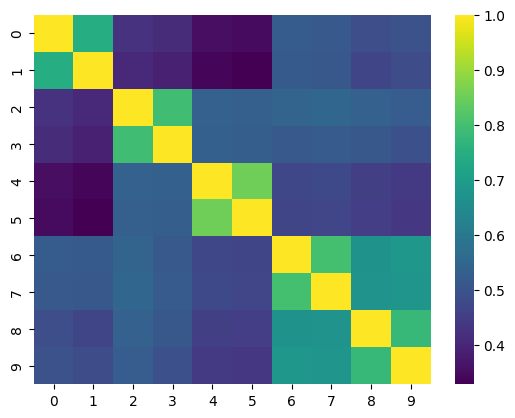

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sim_path = 'output/flower_experiments/SmolLM-135M/flower_clustered_aya_dataset_clustered_c10s10_i10_b16a1_l1024_r8a16_20250909150309/similarity_B_round1.npy'
sim = np.load(sim_path)

sns.heatmap(sim, cmap="viridis")
plt.show()